In [1]:
from pathlib import Path
import os
from glob import glob
import time
import datetime
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
from compress_vs2 import Compression_vs2
import pickle

c:\Users\loren\anaconda3\envs\cs_HeAims\Lib\site-packages\codecarbon\core\gpu.py:4: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml


In [3]:
from codecarbon import EmissionsTracker

In [4]:
#Ram
import psutil
import threading

In [5]:
import gc
# Run garbage collection
gc.collect()


0

In [6]:
def monitor_memory(stop_event, mem_usage, sampling_interval=0.1):
    """
    Monitor the memory usage of the current process at regular intervals.
    """
    process = psutil.Process(os.getpid())
    while not stop_event.is_set():
        mem = process.memory_info().rss / (1024 ** 2)  # Convert bytes to MB
        mem_usage.append(mem)
        time.sleep(sampling_interval)

In [7]:
def monitor_resources(stop_event, cpu_usage, mem_usage, sampling_interval=0.1):
    """
    Monitor CPU and memory usage of the current process at regular intervals.
    - cpu_usage: list to store CPU usage (%) over time
    - mem_usage: list to store memory usage (MB) over time
    """
    process = psutil.Process(os.getpid())
    
    while not stop_event.is_set():
        # CPU percent since last call (per process)
        cpu = process.cpu_percent(interval=None)
        # Memory usage (RSS in MB)
        mem = process.memory_info().rss / (1024 ** 2)
        
        cpu_usage.append(cpu)
        mem_usage.append(mem)
        
        time.sleep(sampling_interval)

In [48]:
#parameter 
folder_audio=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\Audio"
folder_compress=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\Compressed_Audio"
folder_tracking=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\tracking"
converter_path="c:/Users/loren/Downloads/ffmpeg-master-latest-win64-gpl-shared/ffmpeg-master-latest-win64-gpl-shared/bin/ffmpeg.exe"

method_compression="aac"  #between mp3, acc, ogg, flac
parameter_compression="96k" #for mp3 ; 96k/192k/320k, flac;0/6/12, ogg:0/5/10  , aac; 96k/192k/320k

emissions_file = Path(folder_tracking) / f"emissions_output_{method_compression}_{parameter_compression}.csv"

In [ ]:
# Initialize tracker and your compression class
compression = Compression_vs2(folder_audio, folder_compress, method_compression, parameter_compression ,converter_path)


# Lists to store metrics
cpu_usage, mem_usage = [], []
sampling_interval = 0.1  # Adjust as needed
stop_event = threading.Event()


# Start resource monitoring in background
monitor_thread = threading.Thread(target=monitor_resources, args=(stop_event,cpu_usage, mem_usage, sampling_interval))
init_time = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S.%f")[:-5]
print(init_time)
monitor_thread.start()

# Start emissions tracking
tracker = EmissionsTracker(output_file=str(emissions_file))
tracker.start()

# Run compression
starting = time.time()
times=compression.compress()
end=time.time()
execution_time_baseline = time.time() - starting


# Stop trackers
tracker.stop()
stop_event.set()
monitor_thread.join()



print(execution_time_baseline)

In [10]:
execution_time_baseline

361.2744538784027

In [11]:
# Compute summary statistics
# Compute summary statistics
avg_cpu = sum(cpu_usage) / len(cpu_usage)
peak_mem = max(mem_usage)

print(f"Average CPU usage: {avg_cpu:.2f}%")
print(f"Peak memory usage: {peak_mem:.2f} MB")
#print(f"Elapsed time: {end - starting :.2f} s")

# Calculate memory usage statistics during prediction
if mem_usage:
    min_mem = min(mem_usage)
    max_mem = max(mem_usage)
    avg_mem = sum(mem_usage) / len(mem_usage)
    print(f"Memory usage during prediction:")
    print(f"Minimum: {min_mem:.4f} MB")
    print(f"Maximum: {max_mem:.4f} MB")
    print(f"Average: {avg_mem :.4f} MB")
else:
    print("No memory usage data collected.")

Average CPU usage: 4.15%
Peak memory usage: 555.85 MB
Memory usage during prediction:
Minimum: 204.2227 MB
Maximum: 555.8477 MB
Average: 335.4709 MB


In [14]:
#create time_chain dataset with time for each ram value
start_time_str = init_time
length = len(mem_usage)
sampling_interval = 0.1
# Convert the starting time string to a datetime object
start_time = datetime.datetime.strptime(start_time_str, '%Y-%m-%d %H:%M:%S.%f')
# Create a list of timestamps based on the starting time, length, and sampling interval
time_chain = [start_time + datetime.timedelta(seconds=i * sampling_interval) for i in range(length)]
time_chain_str = [time.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3] for time in time_chain]

time_chain_df = pd.DataFrame({'Timestamp': time_chain_str, 'Memory usage': mem_usage, 'CPU usage':cpu_usage })

In [15]:

time_objects = [datetime.datetime.strptime(ts, '%Y-%m-%d %H:%M:%S.%f') for ts in times]
events_df=pd.DataFrame({'Timestamp': time_objects, 'event': [f for f in os.listdir(folder_audio) if f.endswith(".WAV") or f.endswith(".wav")]})


time_chain_df['Timestamp'] = pd.to_datetime(time_chain_df['Timestamp'])
events_df['Timestamp'] = pd.to_datetime(events_df['Timestamp'])
merged_df=pd.merge(time_chain_df, events_df, on='Timestamp', how='left', sort=True)
merged_df.to_csv(f'{folder_tracking}/Ram_usage_{method_compression}_{parameter_compression}.csv')

In [19]:
merged_df.iloc[0,0]

Timestamp('2025-10-08 15:06:53.600000')

In [21]:
merged_df.iloc[-1,0]-merged_df.iloc[0,0]

Timedelta('0 days 00:04:05.900000')

In [22]:
save_path=f'{folder_tracking}/time_execution_{method_compression}_{parameter_compression}.txt'
with open(save_path, "w") as f:
    f.write(f"time execution: {execution_time_baseline}")

# Read Tracking results

In [32]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
path_tracking=r"C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking"

file_paths = glob.glob(f"{path_tracking}/Ram_*.csv")


In [34]:
for index, item in enumerate(file_paths):
    print(index, item)

0 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_aac_144k.csv
1 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_aac_56k.csv
2 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_aac_8k.csv
3 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_compression_0.1.csv
4 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_compression_0.2.csv
5 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_compression_0.4.csv
6 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_flac_0.csv
7 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_flac_2.csv
8 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_flac_4.csv
9 C:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\tracking\Ram_usage_mp3_128.csv
10 C:\Users\loren\Documents\Postdoc\Com

In [39]:
file=file_paths[5]
print(file[-21:-1])
ram=pd.read_csv(file)

e_compression_0.4.cs


In [40]:
cpu_usage=ram.loc[:,"CPU usage"].copy()

mem_usage=ram.loc[:,"Memory usage"].copy()
# Compute summary statistics
# Compute summary statistics
avg_cpu = sum(cpu_usage) / len(cpu_usage)
peak_mem = max(mem_usage)

print(f"Average CPU usage: {avg_cpu:.2f}%")
print(f"Peak memory usage: {peak_mem:.2f} MB")
#print(f"Elapsed time: {end - starting :.2f} s")

# Calculate memory usage statistics during prediction

min_mem = min(mem_usage)
max_mem = max(mem_usage)
avg_mem = sum(mem_usage) / len(mem_usage)
print(f"Memory usage during prediction:")
print(f"Minimum: {min_mem:.4f} MB")
print(f"Maximum: {max_mem:.2f} MB")
print(f"Average: {avg_mem :.2f} MB")


Average CPU usage: 92.04%
Peak memory usage: 803.75 MB
Memory usage during prediction:
Minimum: 155.2852 MB
Maximum: 803.75 MB
Average: 623.44 MB


# Create dataset

In [9]:
from preprocess_vs2 import Preprocessing
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle


In [10]:
selected_species = "thyolo" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())



Loaded settings for: thyolo
{'sample_rate': 32000, 'lowpass_cutoff': 3100, 'downsample_rate': 6400, 'nyquist_rate': 3200, 'segment_duration': 1, 'nb_negative_class': 40, 'annotation_extension': '.svl', 'audio_extension': '.WAV', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1500, 'f_max': 3000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Thyolo'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'thyolo-alethe', 'negative_class': 'noise'}


In [11]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo"

config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.2"

In [12]:
preprocess = Preprocessing(
            **config.preprocessing.dict(),
            species_folder=config.data.species_folder,
            positive_class=config.data.positive_class,
            negative_class=config.data.negative_class,
        )

In [13]:
#parameter_list=["8k","40k", "96k"]
#for parameter_compression in parameter_list : 
    
types=[ "train", "val", "test"]

for dataset_type in types:
    print(dataset_type)
    if dataset_type=="train":
        X_calls, Y_calls = preprocess.create_dataset(dataset_type, method_compression=method_compression, parameter_compression=parameter_compression, preprocessing=True, data_augmentation=True, noise_reduction=False)
    else:
        X_calls, Y_calls = preprocess.create_dataset(dataset_type, method_compression=method_compression, parameter_compression=parameter_compression, preprocessing=True, data_augmentation=False,  noise_reduction=False)
    Y = preprocess._one_hot_encode(Y_calls)
    
    #save data into pickle files
    saving_path=Path(preprocess.species_folder, dataset_type)       
    if method_compression != None : 
        with open(Path(saving_path, str(config.data.positive_class) + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression+ ".pkl"), "wb") as f:
                                pickle.dump(X_calls, f) 
    else : 
        with open(Path(saving_path, str(config.data.positive_class) + "_X_" + dataset_type + ".pkl"), "wb") as f:
                                pickle.dump(X_calls, f) 

        with open(Path(saving_path, str(config.data.positive_class) + "_Y_" + dataset_type + ".pkl"), "wb") as f:
                                pickle.dump(Y, f)    
    

train
Processing: 20201117_040000
Processing: 20201117_043000
Processing: 20201117_050000
Processing: 20201117_053000
Processing: 20201117_060000
Processing: 20201117_063000
Processing: 20201117_070000
Processing: 20201117_073000
Processing: 20201117_080000
Processing: 20201117_163000
Processing: 20201117_170000
Processing: 20201117_173000
Processing: 20201118_040000
Processing: 20201118_043000
Processing: 20201118_050000
Processing: 20201118_053000
Processing: 20201118_060000
Processing: 20201118_063000
Processing: 20201118_073000
Processing: 20201118_080000
Processing: 20201118_163000
Processing: 20201118_170000
Processing: 20201124_040000
Processing: 20201124_043000
Processing: 20201124_050000
Processing: 20201124_053000
Processing: 20201124_060000
Processing: 20201128_151800
Processing: 20201128_152400
Processing: 20201128_152500
Processing: 20201128_152800
Processing: 20201128_171600
Processing: 20201128_171700
Processing: 20201128_171800
Processing: 20201204_043800
Processing: 20

In [14]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
        """Loads the dataset from the save path"""
        # Load X dataset         
        if method_compression!=None:
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression + ".pkl"), "rb") as f:
                X = pickle.load(f)
            print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}_{method_compression}_{parameter_compression}")
        else : 
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + ".pkl"), "rb") as f:
                X = pickle.load(f)
            print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}_baseline")
        
        #load Y
        with open(Path(species_folder, dataset_type, species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
                Y = pickle.load(f)   
        
        return X, Y

In [15]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="train", method_compression=method_compression, parameter_compression=parameter_compression)
X_test, Y_test= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="test", method_compression=method_compression, parameter_compression=parameter_compression)
X_val, Y_val= load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val", method_compression=method_compression, parameter_compression=parameter_compression)
Y=Y_val.copy()
X=X_val.copy()

Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/train_cs_0.2
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/test_cs_0.2
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/val_cs_0.2


In [16]:
print("number segments training dataset : ", len(X_train), len(Y_train))
print("number segments validation dataset : ", len(X_val),len(Y_val))
print("number segments testing dataset : ", len(X_test),len(Y_test))

number segments training dataset :  14170 14170
number segments validation dataset :  4616 4616
number segments testing dataset :  6257 6257


In [17]:
index_positive=np.where(np.argmax(Y, axis=1)==1)[0]
index_negative=np.where(np.argmax(Y, axis=1)==0)[0]

In [18]:
index_p=np.random.choice(index_positive, size=12, replace=False)
index_n=np.random.choice(index_negative, size=12, replace=False)

In [65]:
len(index_positive)

1596

In [66]:
len(index_negative)

3020

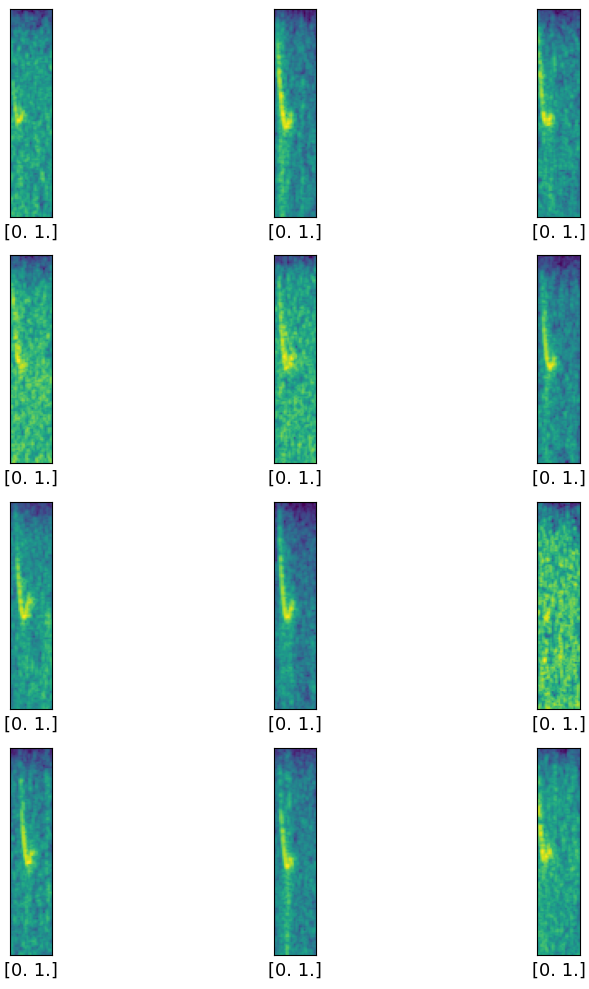

In [20]:
index_p=np.random.choice(index_positive, size=12, replace=False)

fig = plt.figure(figsize=(10,10))
w=0
for i in index_p:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X[i],  origin='lower')
    plt.xlabel(Y[i], fontsize=13)
    w+=1
plt.tight_layout()



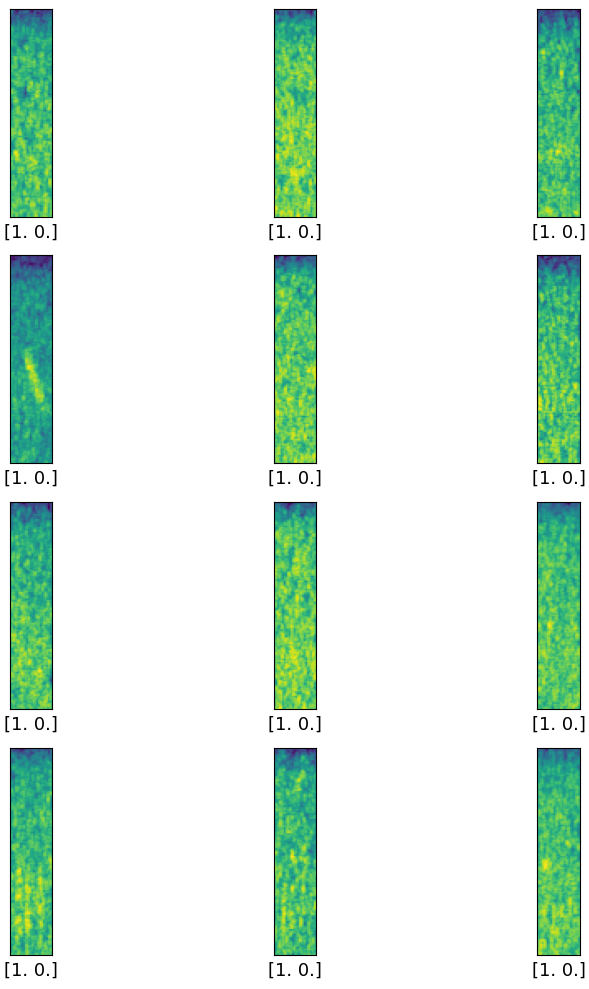

In [21]:

index_n=np.random.choice(index_negative, size=12, replace=False)
fig = plt.figure(figsize=(10,10))
w=0
for i in index_n:
    plt.subplot(4,3,w+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X[i],  origin='lower')
    plt.xlabel(Y[i], fontsize=13)
    w+=1
plt.tight_layout()

## Train the CNN

In [22]:
from model import Model

In [23]:

from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle

In [24]:
selected_species = "thyolo" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())

Loaded settings for: thyolo
{'sample_rate': 32000, 'lowpass_cutoff': 3100, 'downsample_rate': 6400, 'nyquist_rate': 3200, 'segment_duration': 1, 'nb_negative_class': 40, 'annotation_extension': '.svl', 'audio_extension': '.WAV', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1500, 'f_max': 3000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Thyolo'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'thyolo-alethe', 'negative_class': 'noise'}


In [25]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo"
config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.2"

In [5]:
config.cnn_architecture.dict()

{'conv_layers': 1,
 'conv_filters': 8,
 'dropout_rate': 0.5,
 'conv_kernel': 8,
 'max_pooling_size': 4,
 'fc_units': 32,
 'fc_layers': 2,
 'conv_padding': None,
 'stride_maxpool': None}

In [26]:
#Thyolo : 
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 2


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=64

In [7]:
#PTW : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=64


In [102]:
#Gibbon : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 8
config.cnn_architecture.dropout_rate = 0.5
config.cnn_architecture.fc_units = 32
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 50
config.model.batch_size=128

In [27]:
config.model.dict()


{'optimizer_name': 'adam',
 'loss_function_name': 'cross_entropy',
 'num_epochs': 50,
 'batch_size': 64,
 'learning_rate': 0.001,
 'shuffle': True,
 'metric': 'f1'}

In [28]:
config.model.num_epochs=100

In [29]:
if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    save_path.mkdir(parents=True, exist_ok=True)
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    save_path.mkdir(parents=True, exist_ok=True)
print(save_path)

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\results\thyolo-alethe_cs_0.2


In [30]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
        """Loads the dataset from the save path"""
        # Load the dataset
        if method_compression!=None:
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression + ".pkl"), "rb") as f:
                X = pickle.load(f)
        else : 
            print("load baseline")
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + ".pkl"), "rb") as f:
                X = pickle.load(f)


        with open(Path(species_folder, dataset_type, species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
            Y = pickle.load(f)
        
        print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}")
        return X, Y



In [31]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)

Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/train
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/val


In [32]:
print(f"Val set size: {len(X_val)}")
print(f"Train set size: {len(X_train)}")


Val set size: 4616
Train set size: 14170


In [12]:
np.unique(np.argmax(Y_train, axis=1), return_counts=True)

(array([0, 1]), array([7086, 7084]))

In [13]:
Y_train.shape

(14170, 2)

In [14]:
X_train.shape

(14170, 128, 26)

In [33]:
del model

In [34]:
model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict()
,
        )



In [35]:
config.cnn_architecture.dict()

{'conv_layers': 2,
 'conv_filters': 16,
 'dropout_rate': 0.3,
 'conv_kernel': 8,
 'max_pooling_size': 2,
 'fc_units': 64,
 'fc_layers': 2,
 'conv_padding': None,
 'stride_maxpool': None}

In [36]:
model

BaseCNN(
  (conv_layers): Sequential(
    (conv0): Conv2d(1, 16, kernel_size=(8, 8), stride=(1, 1))
    (bn0): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.3, inplace=False)
    (maxpool0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (conv1): Conv2d(16, 16, kernel_size=(8, 8), stride=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.3, inplace=False)
    (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (fc0): Linear(in_features=416, out_features=64, bias=True)
    (relu0): ReLU()
    (dropout0): Dropout(p=0.3, inplace=False)
    (fc1): Linear(in_features=64, out_features=64, bias=True)
    (relu1): ReLU()
    (dropout1): Dropout(p=0.3, inplace=False)
  )
  (output_layer): Linear(in_features=64, out_feat

In [37]:
"""
n_neg = 7084
n_pos = 2491

class_weights = [1.0, n_neg / n_pos]  # [1.0, 2.84]
"""

if method_compression!=None:
    model_name=method_compression+"_"+parameter_compression
else : 
    model_name="baseline"
train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)

Training:  47%|████▋     | 47/100 [01:15<01:25,  1.61s/epoch, lr=6.25e-05, train_loss=0.3155, val_loss=0.3212, best_val=0.3206]

Early stopping triggered at epoch 48


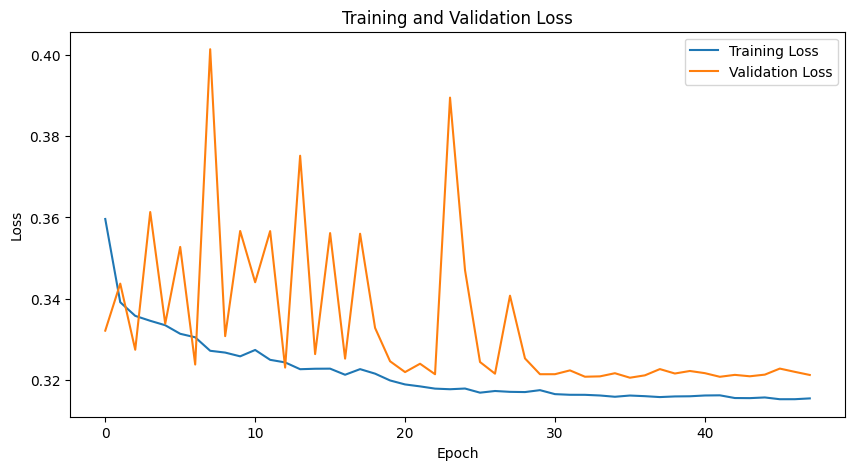

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot( val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [43]:
baseline_metric, baseline_metric_name = model.evaluate(
            X_val=X_val, Y_val=Y_val
        )
baseline_trainable_params = model.get_number_of_parameters()
print(baseline_metric)

0.9883976168077767


## Evaluate the model

In [44]:
import torch
import os
from evaluation import Evaluation
from model import Model

In [45]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.metrics import precision_recall_curve, f1_score
import pickle

In [46]:
selected_species = "thyolo" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())


Loaded settings for: thyolo
{'sample_rate': 32000, 'lowpass_cutoff': 3100, 'downsample_rate': 6400, 'nyquist_rate': 3200, 'segment_duration': 1, 'nb_negative_class': 40, 'annotation_extension': '.svl', 'audio_extension': '.WAV', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1500, 'f_max': 3000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Thyolo'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'thyolo-alethe', 'negative_class': 'noise'}


In [47]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo"
config.preprocessing.audio_extension=".npy"

method_compression="cs"
parameter_compression="0.2"

if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
print(save_path)

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\results\thyolo-alethe_cs_0.2


In [48]:


if method_compression!=None:
    model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
else : 
    model_name="baseline_cnn_state.pth"


model_path = os.path.join(save_path, model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model.load_cnn(model_path, device)

In [49]:
overlap=0.10
nb_to_group=0
threshold=0.8
step_size=1

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                step_size=step_size,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

In [50]:
evaluation.run(model, type="val", test_type="testing_dataset")

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\val
Evaluating...
f1 score : 0.9883317565436771
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3020
           1       0.99      0.98      0.99      1596

    accuracy                           0.99      4616
   macro avg       0.99      0.99      0.99      4616
weighted avg       0.99      0.99      0.99      4616

[[3012    8]
 [  29 1567]]


(0.9883317565436771,
 array([[3012,    8],
        [  29, 1567]]))

In [51]:
#with step_size = 1
evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

creating the folder
Processing file: ['20201130_040000']
2026-03-17 16:14:57.8 Processing file: ['20201130_040000'] 
No amplitudes to predict found on disk
2026-03-17 16:14:57.8 Load 20201130_040000 data 
Filtering...
Downsampling...
2026-03-17 16:15:03.1 Create list of spectrograms
Saved amplitudes to predict to disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201130_040000_amplitudes_to_predict.npy
Predicting...
Total windows predicted: 1794
Step size used: 1
Expected windows for 1.0 step: ~1794
Expected windows for 0.5 step: ~3589
Positive predictions: 116
Threshold used: 0.8
First 5 start times: [0 1 2 3 4]
Last 5 start times: [1789 1790 1791 1792 1793]
Total positive intervals before merge: 116
Total merged intervals: 105
Done
Processing file: ['20201130_043000']
2026-03-17 16:15:06.2 Processing file: ['20201130_043000'] 
No amplitudes to predict found on disk
2026-03-17 16:15:06.2 Load 20201130_043000 data 
Filtering...
Downsampl

(np.float64(0.7733934611048479),
 array([[ 1029,    36],
        [  567, 20679]]),
 150.18378162384033,
 np.float64(0.9661971830985916),
 np.float64(0.6447368421052632))

In [11]:
#with step_size = 0.5
evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

clean the folder
Processing file: ['20201130_040000']
2026-03-17 15:02:48.8 Processing file: ['20201130_040000'] 
No amplitudes to predict found on disk
2026-03-17 15:02:48.8 Load 20201130_040000 data 
Filtering...
Downsampling...
2026-03-17 15:02:54.0 Create list of spectrograms
Saved amplitudes to predict to disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201130_040000_amplitudes_to_predict.npy
Predicting...
Total windows predicted: 3588
Step size used: 0.5
Expected windows for 1.0 step: ~1794
Expected windows for 0.5 step: ~3589
Positive predictions: 184
Threshold used: 0.8
First 5 start times: [0.  0.5 1.  1.5 2. ]
Last 5 start times: [1791.5 1792.  1792.5 1793.  1793.5]
Total positive intervals before merge: 184
Total merged intervals: 84
Done
Processing file: ['20201130_043000']
2026-03-17 15:03:12.5 Processing file: ['20201130_043000'] 
No amplitudes to predict found on disk
2026-03-17 15:03:12.5 Load 20201130_043000 data 
Filt

(np.float64(0.6459525756336877),
 array([[  790,    60],
        [  806, 20657]]),
 354.58160305023193,
 np.float64(0.9294117647058824),
 np.float64(0.4949874686716792))

In [8]:
thresholds=[0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
Precision=[]
Recall=[]
overlap=0.10
nb_to_group=0
for threshold in thresholds : 


    print("Threshold : ", threshold)
    evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )
    _, matrice, _ , precision, recall= evaluation.run(model, type="val", test_type="entire_files", preprocessing_arg=True)

    Precision.append(precision)
    Recall.append(recall)


    
    

Threshold :  0
clean the folder
Processing file: ['20201130_040000']
2026-03-17 15:47:11.1 Processing file: ['20201130_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201130_040000_amplitudes_to_predict.npy
Predicting...
Total windows predicted: 1794
Step size used: 1
Expected windows for 1.0 step: ~1794
Expected windows for 0.5 step: ~3589
Positive predictions: 1794
Threshold used: 0
First 5 start times: [0 1 2 3 4]
Last 5 start times: [1789 1790 1791 1792 1793]
Total positive intervals before merge: 1794
Total merged intervals: 1
Done
Processing file: ['20201130_043000']
2026-03-17 15:47:11.4 Processing file: ['20201130_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201130_043000_amplitudes_to_predict.npy
Predicting...
Total windows predicted: 1794
Step size used: 1
Expected windows for 1.0 step: ~17

KeyboardInterrupt: 

In [37]:
np.asarray(Precision)

array([0.9975    , 0.97710718, 0.97980871, 0.97948164, 0.98150163,
       0.98138007, 0.98232044, 0.98435754, 0.98419865, 0.98514286,
       0.99799197])

In [26]:
np.asarray(Recall)

array([0.99706745, 0.85043988, 0.84750733, 0.83870968, 0.83870968,
       0.82991202, 0.82111437, 0.80938416, 0.79472141, 0.7829912 ,
       0.39002933])

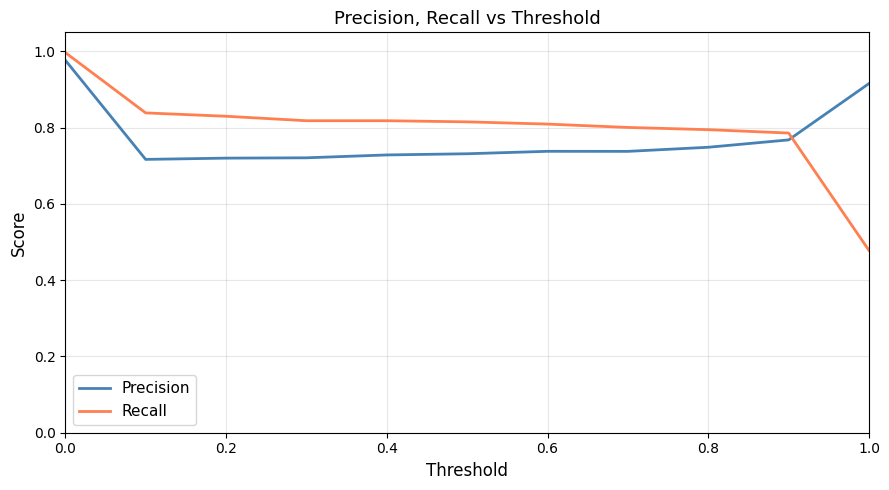

In [34]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(np.asarray(thresholds), np.asarray(Precision), color='steelblue', lw=2, label='Precision')
ax.plot(np.asarray(thresholds), np.asarray(Recall), color='coral', lw=2, label='Recall')

ax.set_xlabel('Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision, Recall vs Threshold', fontsize=13)
ax.set_xlim([min(thresholds), max(thresholds)])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_curves.png', dpi=150, bbox_inches='tight')
plt.show()

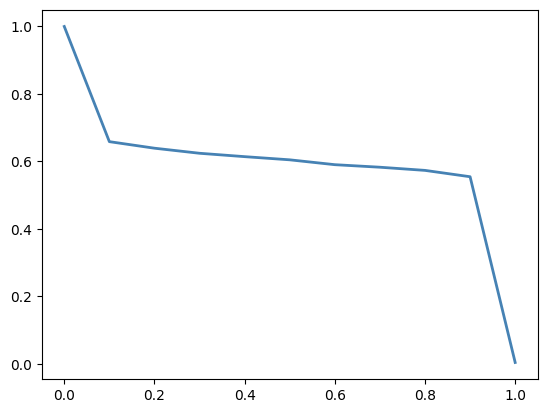

In [43]:
plt.plot(np.asarray(thresholds), np.asarray(Recall),  color='steelblue', lw=2)

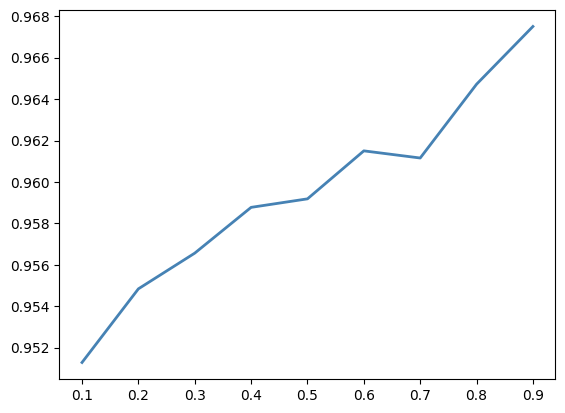

In [16]:
plt.plot(np.asarray(thresholds), np.asarray(Precision),  color='steelblue', lw=2)

In [52]:
threshold=0.8
overlap=0.10
nb_to_group=0
step_size=1

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                step_size=step_size,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )
_, matrice, _ , precision, recall= evaluation.run(model, type="test", test_type="entire_files", preprocessing_arg=True)

clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:19:01.1 Processing file: ['20201201_040000'] 
No amplitudes to predict found on disk
2026-03-17 16:19:01.1 Load 20201201_040000 data 
Filtering...
Downsampling...
2026-03-17 16:19:06.4 Create list of spectrograms
Saved amplitudes to predict to disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Total windows predicted: 1794
Step size used: 1
Expected windows for 1.0 step: ~1794
Expected windows for 0.5 step: ~3589
Positive predictions: 80
Threshold used: 0.8
First 5 start times: [0 1 2 3 4]
Last 5 start times: [1789 1790 1791 1792 1793]
Total positive intervals before merge: 80
Total merged intervals: 69
Done
Processing file: ['20201201_043000']
2026-03-17 16:19:09.4 Processing file: ['20201201_043000'] 
No amplitudes to predict found on disk
2026-03-17 16:19:09.4 Load 20201201_043000 data 
Filtering...
Downsampling...

## Loop of training of CNN + validation

In [1]:
import torch
import os
from evaluation import Evaluation
from model import Model
import shutil

c:\Users\loren\anaconda3\envs\cs_HeAims\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
from settings import Config
from config_species import get_settings
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pickle
import pandas as pd
import gc


In [3]:
selected_species = "thyolo" #"thyolo" # gibbon / ptw
settings = get_settings(selected_species)
config = Config(settings) # Pass settings to your config object
print("Loaded settings for:", selected_species)
print(config.preprocessing.dict())
print(config.data.dict())




Loaded settings for: thyolo
{'sample_rate': 32000, 'lowpass_cutoff': 3100, 'downsample_rate': 6400, 'nyquist_rate': 3200, 'segment_duration': 1, 'nb_negative_class': 40, 'annotation_extension': '.svl', 'audio_extension': '.WAV', 'n_fft': 1024, 'hop_length': 256, 'n_mels': 128, 'f_min': 1500, 'f_max': 3000}
{'force_recreate_dataset': False, 'keep_in_memory': False, 'species_folder': WindowsPath('E:/Bioacoustics_compressed_sensing/Thyolo'), 'train_size': 0.8, 'test_size': 0.2, 'reshuffle': False, 'positive_class': 'thyolo-alethe', 'negative_class': 'noise'}


In [6]:
config.data.species_folder=r"c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo"
config.preprocessing.audio_extension=".npy"



method_compression="cs"
parameter_compression="0.2"



In [7]:
if method_compression!=None : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
    save_path.mkdir(parents=True, exist_ok=True)
else : 
    save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
    save_path.mkdir(parents=True, exist_ok=True)
print(save_path)

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\results\thyolo-alethe_cs_0.2


In [8]:
def load_dataset(species_folder, species, dataset_type="train", method_compression=None, parameter_compression=None) -> tuple:
        """Loads the dataset from the save path"""
        # Load the dataset
        if method_compression!=None:
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + "_" + method_compression + "_"+ parameter_compression + ".pkl"), "rb") as f:
                X = pickle.load(f)
        else : 
            with open(Path(species_folder, dataset_type, species + "_X_" + dataset_type + ".pkl"), "rb") as f:
                X = pickle.load(f)


        with open(Path(species_folder, dataset_type, species + "_Y_" + dataset_type + ".pkl"), "rb") as f:
            Y = pickle.load(f)
        
        print("Dataset loaded from " + str(species_folder) + f"/{dataset_type}/{species}_X_{dataset_type}_{method_compression}_{parameter_compression}")
        return X, Y

In [9]:
X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)

Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/train/thyolo-alethe_X_train_cs_0.2
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/val/thyolo-alethe_X_val_cs_0.2


In [10]:
Y_train.shape

(14170, 2)

In [11]:
X_train.shape

(14170, 128, 26)

In [12]:
config.cnn_architecture.dict()

{'conv_layers': 1,
 'conv_filters': 8,
 'dropout_rate': 0.5,
 'conv_kernel': 8,
 'max_pooling_size': 4,
 'fc_units': 32,
 'fc_layers': 2,
 'conv_padding': None,
 'stride_maxpool': None}

In [13]:
#Thyolo : 
config.cnn_architecture.conv_layers = 2
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 2


config.model.learning_rate = 0.001
config.model.num_epochs = 100
config.model.batch_size=64

In [11]:
#PTW : 
config.cnn_architecture.conv_layers = 1
config.cnn_architecture.fc_layers = 2
config.cnn_architecture.conv_kernel = 8
config.cnn_architecture.conv_filters = 16
config.cnn_architecture.dropout_rate = 0.3
config.cnn_architecture.fc_units = 64
config.cnn_architecture.max_pooling_size = 4


config.model.learning_rate = 0.001
config.model.num_epochs = 100
config.model.batch_size=64


In [14]:
overlap=0.10  #0.25 for ptw and gibbon 0.10 for thyolo
nb_to_group=0 #2 for ptw and gibbon 0 for thyolo
threshold=0.8

evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

0
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/train/thyolo-alethe_X_train_cs_0.2
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo/val/thyolo-alethe_X_val_cs_0.2
{'optimizer_name': 'adam', 'loss_function_name': 'cross_entropy', 'num_epochs': 100, 'batch_size': 64, 'learning_rate': 0.001, 'shuffle': True, 'metric': 'f1'}


Training:  34%|███▍      | 34/100 [01:19<02:35,  2.35s/epoch, lr=1.25e-04, train_loss=0.3163, val_loss=0.3239, best_val=0.3225]


Early stopping triggered at epoch 35


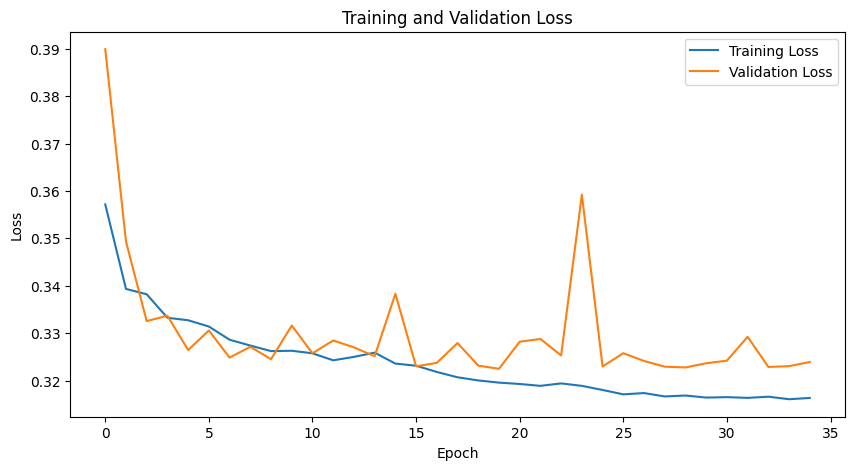

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8857029072082836
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3744
           1       0.89      0.88      0.89      2513

    accuracy                           0.91      6257
   macro avg       0.90      0.90      0.90      6257
weighted avg       0.91      0.91      0.91      6257

[[3459  285]
 [ 289 2224]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:29:53.9 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 16:29:54.1 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  23%|██▎       | 23/100 [00:59<03:18,  2.58s/epoch, lr=2.50e-04, train_loss=0.3178, val_loss=0.3219, best_val=0.3219]


Early stopping triggered at epoch 24


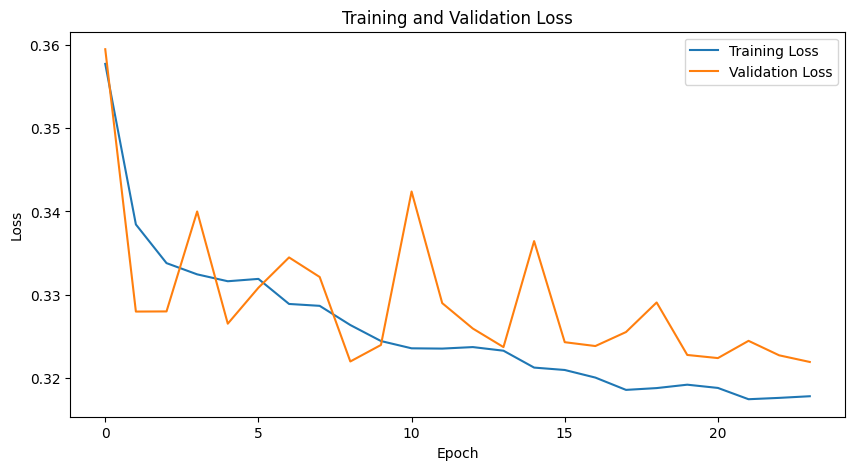

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8925416067392644
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3744
           1       0.92      0.86      0.89      2513

    accuracy                           0.92      6257
   macro avg       0.92      0.91      0.91      6257
weighted avg       0.92      0.92      0.92      6257

[[3562  182]
 [ 341 2172]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:40:46.5 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 16:40:46.7 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  29%|██▉       | 29/100 [00:48<01:57,  1.66s/epoch, lr=2.50e-04, train_loss=0.3176, val_loss=0.3249, best_val=0.3228]

Early stopping triggered at epoch 30


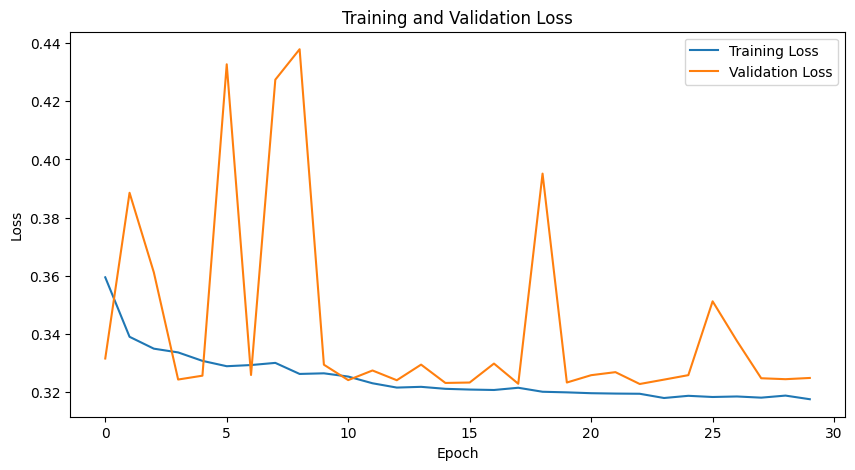

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8846755277560594
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      3744
           1       0.87      0.90      0.88      2513

    accuracy                           0.91      6257
   macro avg       0.90      0.90      0.90      6257
weighted avg       0.91      0.91      0.91      6257

[[3404  340]
 [ 250 2263]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:48:20.2 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 16:48:20.3 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  25%|██▌       | 25/100 [00:26<01:19,  1.06s/epoch, lr=1.25e-04, train_loss=0.3176, val_loss=0.3248, best_val=0.3239]

Early stopping triggered at epoch 26


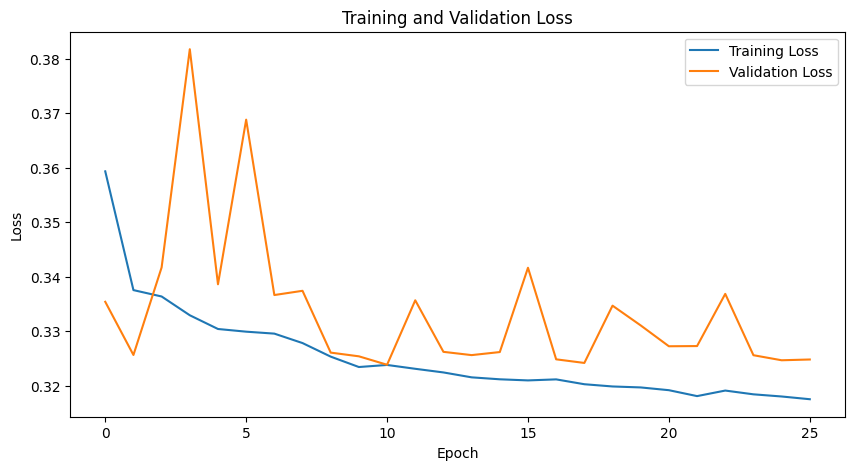

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8929068150208623
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      3744
           1       0.89      0.89      0.89      2513

    accuracy                           0.91      6257
   macro avg       0.91      0.91      0.91      6257
weighted avg       0.91      0.91      0.91      6257

[[3471  273]
 [ 266 2247]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:54:06.2 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 16:54:06.2 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  37%|███▋      | 37/100 [00:33<00:57,  1.10epoch/s, lr=1.25e-04, train_loss=0.3163, val_loss=0.3213, best_val=0.3209]

Early stopping triggered at epoch 38


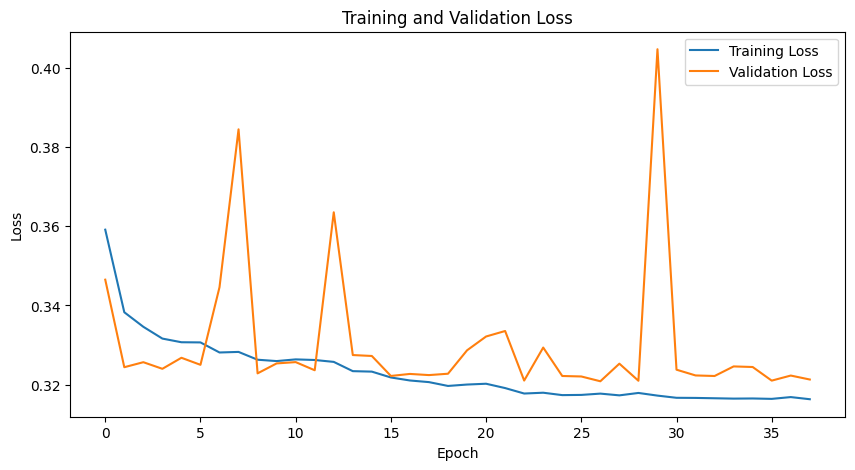

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8924494292008812
              precision    recall  f1-score   support

           0       0.92      0.93      0.93      3744
           1       0.90      0.89      0.89      2513

    accuracy                           0.91      6257
   macro avg       0.91      0.91      0.91      6257
weighted avg       0.91      0.91      0.91      6257

[[3492  252]
 [ 285 2228]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:56:54.9 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 16:56:55.0 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  19%|█▉        | 19/100 [00:18<01:19,  1.02epoch/s, lr=2.50e-04, train_loss=0.3193, val_loss=0.3241, best_val=0.3223]

Early stopping triggered at epoch 20


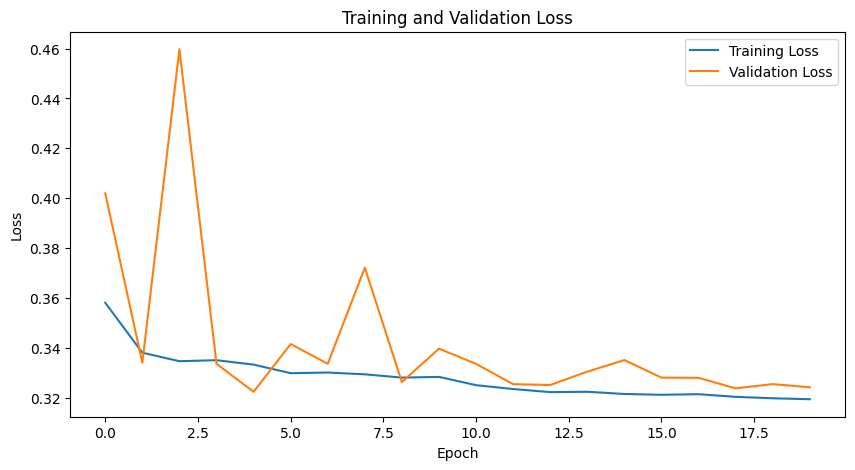

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8865487780647725
              precision    recall  f1-score   support

           0       0.92      0.92      0.92      3744
           1       0.89      0.89      0.89      2513

    accuracy                           0.91      6257
   macro avg       0.90      0.91      0.91      6257
weighted avg       0.91      0.91      0.91      6257

[[3455  289]
 [ 282 2231]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 16:59:27.7 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 16:59:27.7 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  47%|████▋     | 47/100 [00:40<00:45,  1.17epoch/s, lr=1.25e-04, train_loss=0.3157, val_loss=0.3238, best_val=0.3216]

Early stopping triggered at epoch 48


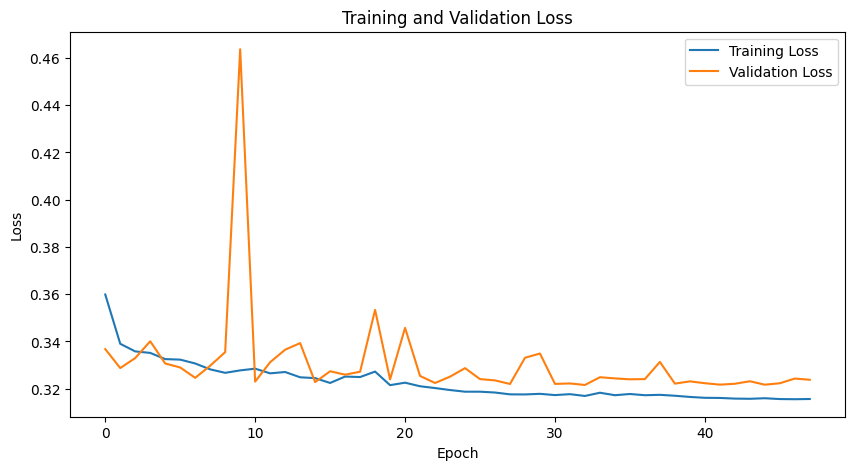

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.891317547055252
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3744
           1       0.91      0.88      0.89      2513

    accuracy                           0.91      6257
   macro avg       0.91      0.91      0.91      6257
weighted avg       0.91      0.91      0.91      6257

[[3518  226]
 [ 311 2202]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 17:02:08.2 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 17:02:08.2 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_t

Training:  24%|██▍       | 24/100 [00:22<01:12,  1.05epoch/s, lr=2.50e-04, train_loss=0.3181, val_loss=0.3289, best_val=0.3233]

Early stopping triggered at epoch 25


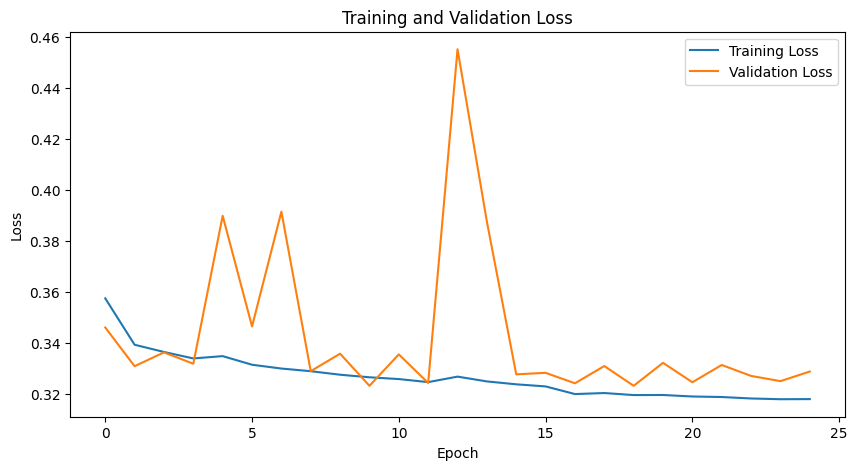

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8927986906710311
              precision    recall  f1-score   support

           0       0.91      0.95      0.93      3744
           1       0.92      0.87      0.89      2513

    accuracy                           0.92      6257
   macro avg       0.92      0.91      0.91      6257
weighted avg       0.92      0.92      0.92      6257

[[3551  193]
 [ 331 2182]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 17:04:31.7 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 17:04:31.8 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  23%|██▎       | 23/100 [00:21<01:11,  1.08epoch/s, lr=2.50e-04, train_loss=0.3181, val_loss=0.3318, best_val=0.3228]

Early stopping triggered at epoch 24


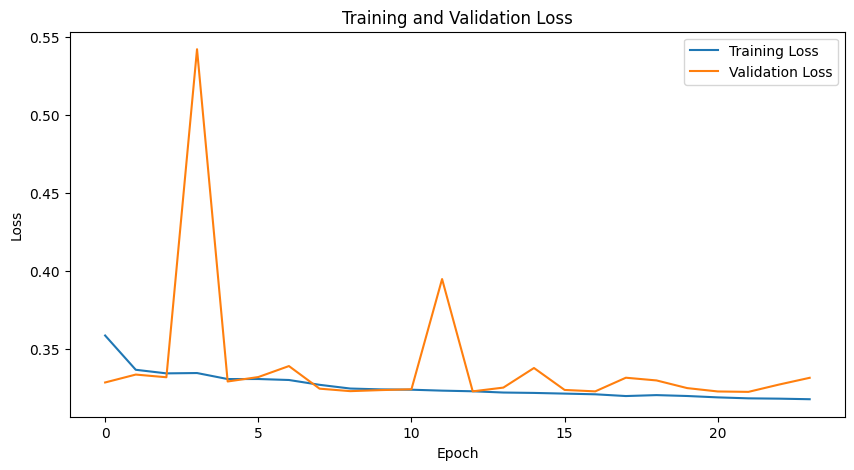

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8842874543239951
              precision    recall  f1-score   support

           0       0.91      0.94      0.92      3744
           1       0.90      0.87      0.88      2513

    accuracy                           0.91      6257
   macro avg       0.91      0.90      0.90      6257
weighted avg       0.91      0.91      0.91      6257

[[3509  235]
 [ 335 2178]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 17:06:50.1 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 17:06:50.1 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

Training:  22%|██▏       | 22/100 [00:20<01:12,  1.08epoch/s, lr=5.00e-04, train_loss=0.3194, val_loss=0.3484, best_val=0.3222]

Early stopping triggered at epoch 23


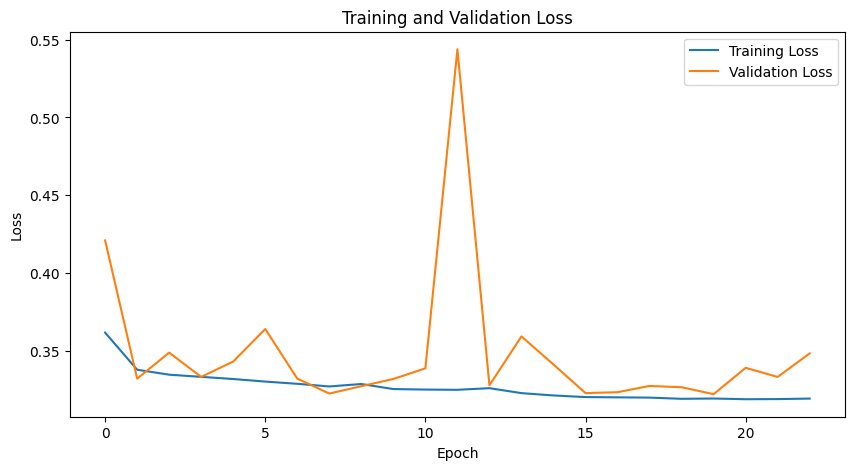

Data Loaded from:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\test
Evaluating...
f1 score : 0.8925318761384335
              precision    recall  f1-score   support

           0       0.92      0.94      0.93      3744
           1       0.91      0.88      0.89      2513

    accuracy                           0.92      6257
   macro avg       0.91      0.91      0.91      6257
weighted avg       0.91      0.92      0.91      6257

[[3521  223]
 [ 308 2205]]
clean the folder
Processing file: ['20201201_040000']
2026-03-17 17:09:13.7 Processing file: ['20201201_040000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_to_predict_.npy\20201201_040000_amplitudes_to_predict.npy
Predicting...
Done
Processing file: ['20201201_043000']
2026-03-17 17:09:13.8 Processing file: ['20201201_043000'] 
Found amplitudes to predict on disk:  c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\Thyolo\amplitudes_

' \n#clean the folder with amplitudes \nif os.path.exists(evaluation.save_amplitudes_path):\n    shutil.rmtree(evaluation.save_amplitudes_path)\n    print(f"Folder \'{evaluation.save_amplitudes_path}\' and its contents deleted successfully.")\nelse:\n    print(f"Folder \'{evaluation.save_amplitudes_path}\' does not exist.")\n'

In [15]:
first_loop=0
last_loop=10

F1_score_full=[]
F1_score=[]

for i in range(first_loop, last_loop): 
    
    
    #clean gpu
    torch.cuda.empty_cache()
    gc.collect()
    
    
    print(i)
    #create folder to save model 
    #dir_out=Path(save_path, f"model_{config.data.positive_class}_{method_compression}_{parameter_compression}_{k}")
    #os.makedirs(dir_out)
    X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
    X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)
    
    #I- Training
    #initialise the model 
    model = Model(save_path,
            input_shape=(1, X_train.shape[1], X_train.shape[2]),
            architecture_args= config.cnn_architecture.dict(),
            **config.model.dict(),
        )
    print(config.model.dict())

    

    #train
    if method_compression!= None : 
        model_name=method_compression+"_"+parameter_compression
    else : 
        model_name="baseline"
    train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=True, patience=15, min_delta=0.0005)
    del model, model_name


    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss')
    plt.plot( val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.savefig(Path(save_path, f"Training_and_Validation_Loss_{i}.png"))
    plt.show()
    


    # II- Evaluation
    #load the saved model
    if method_compression!= None :
        model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
    else : 
        model_name="baseline_cnn_state.pth"
    model_path = os.path.join(save_path, model_name)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = Model.load_cnn(model_path, device)

    f1_score=evaluation.run(model, test_type="testing_dataset")[0]
    f1_score_full=evaluation.run(model, test_type="entire_files", preprocessing_arg=True)[0]

    F1_score.append(f1_score)
    F1_score_full.append(f1_score_full)
    del model, model_name, X_train, X_val, Y_train, Y_val

#save f1 score
df = pd.DataFrame({"F1_score" : np.asarray(F1_score), "F1_score_full" : np.asarray(F1_score_full)})
df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

print("F1_score mean : ", np.mean(np.asarray(F1_score)))  
print("F1_score_full  mean : ", np.mean(np.asarray(F1_score_full)))

""" 
#clean the folder with amplitudes 
if os.path.exists(evaluation.save_amplitudes_path):
    shutil.rmtree(evaluation.save_amplitudes_path)
    print(f"Folder '{evaluation.save_amplitudes_path}' and its contents deleted successfully.")
else:
    print(f"Folder '{evaluation.save_amplitudes_path}' does not exist.")
"""

In [ ]:

overlap=0.10
nb_to_group=0
threshold=0.8
parameters_list=["0", "6","12"]

for parameter_compression in parameters_list : 
    if method_compression!=None : 
        save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_{method_compression}_{parameter_compression}")
        save_path.mkdir(parents=True, exist_ok=True)
    else : 
        save_path=Path(config.data.species_folder, "results", f"{config.data.positive_class}_baseline")
        save_path.mkdir(parents=True, exist_ok=True)
    print(save_path)

    
    evaluation = Evaluation(
                species_folder=config.data.species_folder,
                settings=config,
                overlap=overlap,
                threshold=threshold,
                method_compression=method_compression, 
                parameter_compression=parameter_compression,
                nb_to_group=nb_to_group, 
                force_calc_amplitudes=False,
                audio_extension=config.preprocessing.audio_extension,
            )

    first_loop=0
    last_loop=10

    F1_score_full=[]
    F1_score=[]

    for i in range(first_loop, last_loop): 
      
        #clean gpu
        torch.cuda.empty_cache()
        gc.collect()
        
        
        print(i)
        #create folder to save model 
        #dir_out=Path(save_path, f"model_{config.data.positive_class}_{method_compression}_{parameter_compression}_{k}")
        #os.makedirs(dir_out)
        X_train, Y_train= load_dataset(config.data.species_folder, config.data.positive_class, method_compression=method_compression, parameter_compression=parameter_compression)
        X_val, Y_val=load_dataset(config.data.species_folder, config.data.positive_class, dataset_type="val",method_compression=method_compression, parameter_compression=parameter_compression)
    
        
        #I- Training
        #initialise the model 
        model = Model(save_path,
                input_shape=(1, X_train.shape[1], X_train.shape[2]),
                architecture_args= config.cnn_architecture.dict(),
                **config.model.dict(),
            )

        #train
        if method_compression!= None : 
            model_name=method_compression+"_"+parameter_compression
        else : 
            model_name="baseline"
        train_losses, val_losses =model.train(X_train=X_train, Y_train=Y_train, X_val=X_val, Y_val=Y_val, model_name=model_name, early_stopping=False)
        del model, model_name

        # II- Evaluation
        #load the saved model
        if method_compression!= None :
            model_name=method_compression+"_"+parameter_compression+"_cnn_state.pth"
        else : 
            model_name="baseline_cnn_state.pth"
        model_path = os.path.join(save_path, model_name)
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model = Model.load_cnn(model_path, device)

        f1_score=evaluation.run(model, test_type="testing_dataset")[0]
        f1_score_full=evaluation.run(model, test_type="entire_files", preprocessing_arg=True)[0]

        F1_score.append(f1_score)
        F1_score_full.append(f1_score_full)
        del model, model_name

    #save f1 score
    df = pd.DataFrame({"F1_score" : np.asarray(F1_score), "F1_score_full" : np.asarray(F1_score_full)})
    df.to_csv(Path(save_path, f"{config.data.positive_class}_{method_compression}_{parameter_compression}_f1score_csv.csv"), index=False)

    print("F1_score mean : ", np.mean(np.asarray(F1_score)))  
    print("F1_score_full  mean : ", np.mean(np.asarray(F1_score_full))) 
    
    
    #clean the folder with amplitudes 
    if os.path.exists(evaluation.save_amplitudes_path):
        shutil.rmtree(evaluation.save_amplitudes_path)
        print(f"Folder '{evaluation.save_amplitudes_path}' and its contents deleted successfully.")
    else:
        print(f"Folder '{evaluation.save_amplitudes_path}' does not exist.")
    
    
    del X_train, Y_train, X_val, Y_val, evaluation
    print("Next parameter")


        

c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0
0
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW/train/PTW_X_train_flac_0
Dataset loaded from c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW/val/PTW_X_val_flac_0
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Documents\Postdoc\Compressed_sensing\Data\PTW\results\PTW_flac_0\flac_0_cnn_state.pth!
CNN model state dict saved to c:\Users\loren\Docum

KeyboardInterrupt: 